<a href="https://colab.research.google.com/github/yeatescp01/INFO648/blob/main/Lesson_13/INFO_648_MLP_CA_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score


Neural Networks are very sensitive to input scale.

• Scaling: Keeps all features on similar ranges so gradient descent works properly

• One-Hot Encoding: ANNs require numeric input, so categorical variables must be
converted
Rule:

• Numeric → Scale (MinMax or StandardScaler)

• Categorical → OneHotEncoder

# Regression vs Classification in ANN
## Regression (Continuous Output)
• Model: MLPRegressor

• Output: numeric value

## Classification (Binary or Multi-Class)

• Model: MLPClassifier

• Output: probability → class label

- **MSE** → Punishes big errors (squared)
- **RMSE** → Same idea, but interpretable units
- **MAE** → Simple average error (more forgiving)

**Mean Squared Error (MSE)**

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- Squares the errors  
- Penalizes large mistakes heavily  

**Root Mean Squared Error (RMSE)**

$$
RMSE = \sqrt{MSE}
$$

- Same units as the target variable  
- Easier to interpret than MSE  

**Mean Absolute Error (MAE)**

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

- Average absolute error  
- More robust to outliers than MSE  

In [ ]:
data = pd.read_csv('/content/housing.csv')
new_data = data.dropna().copy() # Explicitly create a copy to avoid SettingWithCopyWarning


In [ ]:
new_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
expensive=new_data['median_house_value'].mean()
#new_data['high_value']=(new_data['median_house_value']>expensive).astype(int)
X = new_data.drop(columns=['median_house_value','longitude', 'latitude'],axis=1)
y = new_data['median_house_value']
#y=new_data['high_value']

print(X.head(20))

    housing_median_age  total_rooms  total_bedrooms  population  households  \
0                 41.0        880.0           129.0       322.0       126.0   
1                 21.0       7099.0          1106.0      2401.0      1138.0   
2                 52.0       1467.0           190.0       496.0       177.0   
3                 52.0       1274.0           235.0       558.0       219.0   
4                 52.0       1627.0           280.0       565.0       259.0   
5                 52.0        919.0           213.0       413.0       193.0   
6                 52.0       2535.0           489.0      1094.0       514.0   
7                 52.0       3104.0           687.0      1157.0       647.0   
8                 42.0       2555.0           665.0      1206.0       595.0   
9                 52.0       3549.0           707.0      1551.0       714.0   
10                52.0       2202.0           434.0       910.0       402.0   
11                52.0       3503.0           752.0 

In [ ]:
X.isna().sum()

,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0
high_value,0


We will change mlp between MLPRegressor and MLPClassifier depending on the target variable.  We will then use the appropriate metrics to assess the model. (RMSE vs Confusion Matrix).

In [ ]:

#  Load Data
#  Preprocessing (CRITICAL for Neural Nets)
# ANNs are sensitive to scale; scaling helps the weights converge faster.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor=ColumnTransformer(
  transformers=[
      ('cat',OneHotEncoder(),['ocean_proximity']),
      ("num",MinMaxScaler(),['housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'])
  ]
 )

# The Model
# We'll use two hidden layers with 50 neurons each.
mlp = MLPRegressor(hidden_layer_sizes=(50, 50, 50),
                   max_iter=300,
                   activation='relu',
                   solver='adam',
                   random_state=42,
                   verbose=True)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', mlp)
])

pipeline.fit(X_train, y_train)



Iteration 1, loss = 27967273688.79243851
Iteration 2, loss = 27893031054.98566437
Iteration 3, loss = 27242501236.56774139
Iteration 4, loss = 24842138993.84023666
Iteration 5, loss = 19596707199.69837189
Iteration 6, loss = 12506302861.49224472
Iteration 7, loss = 7233247717.57855511
Iteration 8, loss = 5412006505.67933178
Iteration 9, loss = 4990937339.98594666
Iteration 10, loss = 4794476453.54754448
Iteration 11, loss = 4651470163.07720089
Iteration 12, loss = 4538821075.29581165
Iteration 13, loss = 4442590588.71320152
Iteration 14, loss = 4356801425.17795372
Iteration 15, loss = 4281703299.02777958
Iteration 16, loss = 4214998430.38881588
Iteration 17, loss = 4155272069.31225061
Iteration 18, loss = 4098616069.87895203
Iteration 19, loss = 4045336859.97822380
Iteration 20, loss = 3992199551.79526186
Iteration 21, loss = 3940079557.96491909
Iteration 22, loss = 3886162090.07134342
Iteration 23, loss = 3832743235.55643606
Iteration 24, loss = 3777950713.99986219
Iteration 25, loss 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['ocean_proximity']),
                                                 ('num', MinMaxScaler(),
                                                  ['housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income'])])),
                ('model',
                 MLPRegressor(hidden_layer_sizes=(50, 50, 50), max_iter=300,
                              random_state=42, verbose=True))])

In [ ]:

# Get predictions
y_pred = pipeline.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**.5

print(f"MAE:  {mae:.2f} (Average absolute miss)")
print(f"RMSE: {rmse:.2f} (Heavily penalizes big misses)")

MAE:  48918.95 (Average absolute miss)
RMSE: 68010.38 (Heavily penalizes big misses)


In [ ]:
#y_pred = pipeline.predict(X_test)
#print(f" Accuracy {accuracy_score(y_test,y_pred):.2f} \n Precision: {precision_score(y_test,y_pred):.2f}\n Recall {recall_score(y_test,y_pred):.2f}")

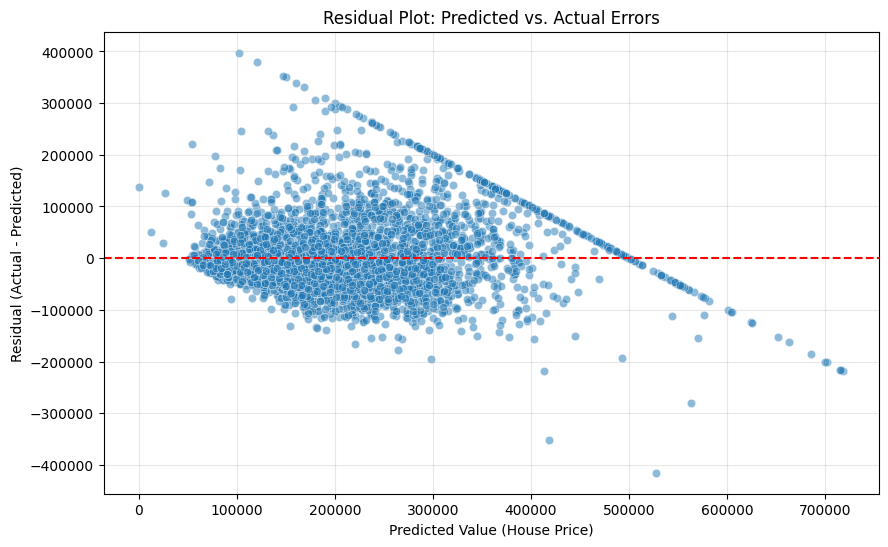

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions for the Test set (the "unseen" data)
y_pred = pipeline.predict(X_test)
residuals = y_test - y_pred

# Create the Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')  # The "Perfect Prediction" line

plt.title('Residual Plot: Predicted vs. Actual Errors')
plt.xlabel('Predicted Value (House Price)')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()